# Executive Summary


The buy-and-hold on DIA ETF (DIA Passive) performs the best out of the three: the portfolio value grows 10 times after 26 years. The active trading strategy on constituent stocks (Stock Active) is the second best with the portfolio value grows 5 times after 26 years. The active trading strategy on DIA ETF (DIA Active) is the worst performing strategy as the portfolio lost value after 26 years.

The alpha in the Fama-French 3-factor model for all three strategies were statistically insignificant, indicating that we did not find evidence that the strategies generated alpha. Among the three strategies, the DIA Passive has the highest Sharpe ratio and Sortino ratio, followed by Stock Active and DIA Active respectively. In terms of Maximum Drawdown, Stock Active has the largest maximum drawdown of $-0.63$, followed closely by DIA Active with $-0.59$. DIA Passive has the lowest maximum drawdown of $-0.52$.

DIA Active lost value was because there were not many buy signals for DIA. Additionally, there were more long/short positions resulting in losses than those gained returns. As a result, DIA Active had a net loss.

The Stock Active underperforms DIA Passive because it generates losses when the stock has low momentum and high volatility. A closer look at Sherwin Williams and UnitedHealth stocks, the two that Stock Active portfolio had the most long position on during 2000-2002, showed that the stocks had low momentum and high volatility. As a result, most of the long positions on these two stocks during the Dotcom bubble resulted in the stop-loss condition triggered. The Stock Active portfolio, therefore, was nearly wiped out during this period.

We tested two methods of improving the performance of the active strategy on individual stocks: adding extra factors or conditions to the strategy and changing the position holding period. 

We add momentum and volatility factors to the strategy to see if the performance improves. The purpose of the momentum factor is to confirm the stock is actually on a growth/lose momentum before entering a long/short position, and the stock is not too volatile that it might trigger a sell signal within the 20-day holding period.

The momentum factor is how much the stock price has risen during the last $10$ days, measured by $g = \frac{\text{Adj Close}[i]}{\text{Adj Close}[i-10]} - 1$ . If $g$ is greater or equal to $0.025$, then the momentum condition is satisfied. The volatility factor considers the standard deviation of the stock price in the last $10$ days. If the stock price standard deviation is lower than $0.015$, the volatility condition is satisfied. Our experiment shows a significant improvement in the Stock Active performance when two new factors are added. The new strategies generated higher win rates for the positions (note: win rate is the percentage of positions that had positive returns). The new active portfolio indeed outperformed the passive portfolio in terms of both ending portfolio value and maximum drawdown. 

We also tested how to active stock portfolio changes when we change the position holding period. Using our given data, the Stock Active portfolio performs the best when we increase the holding period from $20$ days to $30$ days. However, once we increase the holding period to $40$ days and longer, the portfolio performs worse. This means the relationship between the length of holding period and the strategy performance might be quandratic.

We conclude the adding the volatility and momentum factors and adjusting the holding period length will improve the performance of the active strategy. However, further research and experiment is needed to dynamically benchmark or criteria to choose the most optimal parameter values require. We expect that for different economic cycles and different stock movements, the active strategy works best with different combination of parameter values. 


# Backtesting

We are comparing the returns generated by three strategies 
1. Stock Active: We actively take positions on constituent stocks of the DJIA Index using 52-week High/Low and Volume signals.
2. DIA Active: We actively take positions on DIA ETF using 52-week High/Low and Volume signals.
3. DIA Passive: We buy and hold till end of the time period.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
from itertools import product
import matplotlib.dates as mdates

In [2]:
%precision 4
pd.options.display.float_format = '{:.4f}'.format

In [3]:
djia = pd.read_csv('data_djia.csv')
ff3 = pd.read_csv('data_ff3.csv')

In [4]:
djia = djia.merge(ff3[['Date','RF']], on = 'Date', how = 'left')

In [5]:
djia['RF'] = djia['RF']/252

In [6]:
dia = djia[djia['Ticker'] == 'DIA']
dia = dia.reset_index(drop=True)

In [7]:
djia_ex_dia = djia[djia['Ticker'] != 'DIA']
djia_ex_dia = djia_ex_dia.reset_index(drop=True)

## DIA - Active Trading 

In [8]:
djia_ex_dia_derived = (
    djia_ex_dia
    .assign(
        Return=lambda x: x.groupby('Ticker')['Adj Close'].pct_change(), 
        week_high=lambda x: x.groupby('Ticker')['Adj Close'].transform(lambda y: y.rolling(window=252).max()), 
        week_low=lambda x: x.groupby('Ticker')['Adj Close'].transform(lambda y: y.rolling(window=252).min()),
        day_avg_vol=lambda x: x.groupby('Ticker')['Volume'].transform(lambda y: y.rolling(window=20).mean()),
    )
)


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\1538129814.py:4: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  Return=lambda x: x.groupby('Ticker')['Adj Close'].pct_change(),


In [9]:
pre_dia_derived = (
    dia
    .assign(
        Return=lambda x: x['Adj Close'].pct_change(), 
        week_high=lambda x: x['Adj Close'].rolling(window=252).max(), 
        week_low=lambda x: x['Adj Close'].rolling(window=252).min(),
        day_avg_vol=lambda x: x['Volume'].rolling(window=20).mean()
    )
)


In [10]:
entry_price = None
entry_index = None


def dia_func(dia_derived, volume_multiplier, stop_loss_rate):       
    i = 0
    while i < len(dia_derived): # change to while loop.
        # We are checking the long signal for index i
        if dia_derived['Adj Close'].iloc[i] == dia_derived['week_high'].iloc[i] and dia_derived['Volume'].iloc[i] > volume_multiplier * dia_derived['day_avg_vol'].iloc[i]:
            #Enter long position in index i + 1
            dia_derived.loc[i+1, 'position'] = 1
            #Extract entry price for i + 1
            entry_price = dia_derived['Adj Close'].iloc[i]
            entry_index = i
    
            # Check for 5% drop within the next 20 days
            for j in range(i + 1, min(i + 21, len(dia_derived))):
                    if (j - entry_index) < 20: # check if less than 20 days.
                        if dia_derived['Adj Close'].iloc[j] < (1-stop_loss_rate) * entry_price:
                            dia_derived.loc[j+1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j+1  # Resume from the exit point
                            break
                    else: # 20 days have passed.
                        dia_derived.loc[j+1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j+1
                        break
        # We are checking the Short signal for index i
        elif dia_derived['Adj Close'].iloc[i] == dia_derived['week_low'].iloc[i] and dia_derived['Volume'].iloc[i] > volume_multiplier * dia_derived['day_avg_vol'].iloc[i]:
            #Enter short position in index i + 1
            dia_derived.loc[i+1, 'position'] = -1
            #Extract entry price for i + 1
            entry_price = dia_derived['Adj Close'].iloc[i] 
            entry_index = i
        
            # Check for 5% drop within the next 20 days
            for j in range(i + 1, min(i + 21, len(dia_derived))):
                    if (j - entry_index) < 20: # check if less than 20 days.
                        if dia_derived['Adj Close'].iloc[j] > (1+stop_loss_rate) * entry_price:
                            dia_derived.loc[j+1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j+1  # Resume from the exit point
                            break
                    else: # 20 days have passed.
                        dia_derived.loc[j+1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j+1
                        break
    
        i += 1  # Increment i outside the if/else blocks
    
    dia_derived['position'] = dia_derived['position'].ffill()
    dia_derived['Strategy'] = dia_derived['position'] * dia_derived['Return']
    dia_derived['Strategy']= dia_derived['Strategy'].fillna(0)
    dia_derived.loc[dia_derived.index[1:], 'Strategy'] = np.where(
        dia_derived['Strategy'].iloc[1:] == 0, 
        dia_derived['RF'].iloc[1:], 
        dia_derived['Strategy'].iloc[1:]
    )
    return dia_derived

## Constituent stocks - Active Trading

In [11]:
positions_by_ticker = {}

def djia_func(djia_ex_dia_derived, volume_multiplier, stop_loss_rate):
    for ticker in djia_ex_dia_derived['Ticker'].unique():
        df = djia_ex_dia_derived[djia_ex_dia_derived['Ticker'] == ticker].copy().reset_index(drop=True)
        df['position'] = np.nan  # Initialize position column
    
        entry_price = None
        entry_index = None
    
        i = 0
        while i < len(df):
            # Long Entry
            if (
                df['Adj Close'].iloc[i] == df['week_high'].iloc[i]
                and df['Volume'].iloc[i] > volume_multiplier * df['day_avg_vol'].iloc[i]
            ):
                df.loc[i + 1, 'position'] = 1
                entry_price = df['Adj Close'].iloc[i]
                entry_index = i
    
                for j in range(i + 1, min(i + 21, len(df))):
                    if df['Adj Close'].iloc[j] < (1-stop_loss_rate) * entry_price:
                        df.loc[j + 1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j + 1
                        break
                    elif (j - entry_index) == 20:
                        df.loc[j + 1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j + 1
                        break
    
            # Short Entry
            elif (
                df['Adj Close'].iloc[i] == df['week_low'].iloc[i]
                and df['Volume'].iloc[i] > volume_multiplier * df['day_avg_vol'].iloc[i]
            ):
                df.loc[i + 1, 'position'] = -1
                entry_price = df['Adj Close'].iloc[i]
                entry_index = i
    
                for j in range(i + 1, min(i + 21, len(df))):
                    if df['Adj Close'].iloc[j] > (1+stop_loss_rate) * entry_price:
                        df.loc[j + 1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j + 1
                        break
                    elif (j - entry_index) == 20:
                        df.loc[j + 1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j + 1
                        break
    
            i += 1  # Always increment i if no entry/exit triggered
    
        positions_by_ticker[ticker] = df
        
    combined_positions = pd.concat(positions_by_ticker.values(), ignore_index=True)
    combined_positions = combined_positions.set_index(['Date','Ticker']).unstack(level='Ticker')
    combined_positions['position'] = combined_positions['position'].ffill()
    _ = pd.MultiIndex.from_product([['Stock Strategy'],combined_positions['Adj Close'].columns])
    combined_positions[_] = combined_positions['position']*combined_positions['Return']
    combined_positions = combined_positions.stack()
    portfolio = combined_positions.groupby('Date').apply(lambda x: x['position'].abs().sum())
    portfolio = portfolio.to_frame(name = 'Total_Position')
    portfolio['Total Stock Return'] = combined_positions.groupby('Date')['Stock Strategy'].sum()
    portfolio['Strategy'] = portfolio['Total Stock Return']/portfolio['Total_Position']
    portfolio['Strategy'] = portfolio['Strategy'].fillna(0)
    portfolio = portfolio.merge(ff3[['Date','RF']], on = 'Date', how = 'left')
    portfolio['RF'] = portfolio['RF']/252
    return portfolio, combined_positions

In [12]:
# INPUTS FOR VARIABLES:

volume_multiplier = 1.5
stop_loss_rate = 0.05

In [13]:
dia_derived = dia_func(pre_dia_derived, volume_multiplier, stop_loss_rate)
portfolio, combined_positions = djia_func(djia_ex_dia_derived, volume_multiplier, stop_loss_rate)

C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\256507366.py:68: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  combined_positions = combined_positions.stack()


In [14]:
portfolio.loc[dia_derived.index[1:], 'Strategy'] = np.where(
portfolio['Strategy'].iloc[1:] == 0, 
portfolio['RF'].iloc[1:], 
portfolio['Strategy'].iloc[1:]
)

## Comparing Returns of the three strategies

<Figure size 3000x800 with 0 Axes>

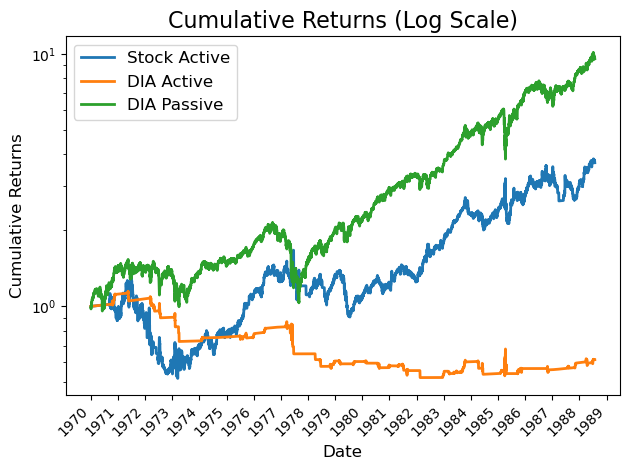

In [15]:
three_strategies = pd.concat([
    portfolio[['Date', 'Strategy']],
    dia_derived[['Strategy', 'Return']]
], axis=1)
three_strategies.columns = ['Date','Stock Active','DIA Active','DIA Passive']

three_strategies = three_strategies.set_index('Date', drop=True)
 
cumulative_returns = three_strategies.add(1).cumprod()

# Plotting with enhancements
plt.figure(figsize=(30, 8))  # Even larger figure for a longer x-axis
cumulative_returns.plot(linewidth=2)  # Thicker lines

plt.semilogy()  # Logarithmic y-axis

plt.title('Cumulative Returns (Log Scale)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns', fontsize=12)

plt.legend(fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_locator(mdates.YearLocator()) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

There are significant differences in the performance of the three strategies. The buy-and-hold performs the best out of the three: the portfolio value grows 10 times after 26 years. The active trading strategy on constituent stocks is the second best with the portfolio value grows 5 times after 26 years. The active trading strategy on DIA ETF is the worst performing strategy as the portfolio lost value after 26 years.
The reason DIA Active lost value was because there were not many buy signals for DIA. Additionally, there were more long/short positions resulting in losses than those gained returns. As a result, DIA Active had a net loss. Further analysis of the other two strategies will be demonstrated in later sections.

# Risk-Return Analysis

In [16]:
three_strategies_ff3 = pd.merge(ff3, three_strategies, on = 'Date', how='inner').dropna().reset_index(drop=True)


In [17]:
three_strategies_ff3['RF'] = three_strategies_ff3['RF']/252
three_strategies_ff3 = three_strategies_ff3.assign(
    Stockactpre = lambda x: x['Stock Active'] - x['RF'],
    DIAactpre = lambda x: x['DIA Active'] - x['RF'],
    DIApassivepre = lambda x: x['DIA Passive'] - x['RF']
)

## Alpha using 3 factor Fama French Model

In [18]:
smf.ols(formula='Stockactpre ~ Q("Mkt-RF") + SMB + HML', data=three_strategies_ff3).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Stockactpre   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     71.24
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.34e-45
Time:                        15:44:58   Log-Likelihood:                 19098.
No. Observations:                6781   AIC:                        -3.819e+04
Df Residuals:                    6777   BIC:                        -3.816e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0003      0.000      1.857      0.063   -1.83e-05       0.001
Q("Mkt-RF")    -0.0017      0.000    -12.201      0.000      -0.002      -0.001
SMB             0.0021      0.000      7.560      0.000       0.002       0.003
HML            -0.0010      0.000     -4.569      0.000      -0.001      -0.001
==============================================================================
Omnibus:                     1762.928   Durbin-Watson:                   2.079
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            68389.174
Skew:                          -0.522   Prob(JB):                         0.00
Kurtosis:                      18.523   Cond. No.                         1.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
smf.ols(formula='DIAactpre ~ Q("Mkt-RF") + SMB + HML', data=three_strategies_ff3).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              DIAactpre   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     219.2
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          9.51e-136
Time:                        15:44:58   Log-Likelihood:                 25537.
No. Observations:                6781   AIC:                        -5.107e+04
Df Residuals:                    6777   BIC:                        -5.104e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -4.117e-05   6.81e-05     -0.605      0.545      -0.000    9.22e-05
Q("Mkt-RF")    -0.0014   5.54e-05    -24.758      0.000      -0.001      -0.001
SMB             0.0009      0.000      8.897      0.000       0.001       0.001
HML            -0.0002   8.81e-05     -2.160      0.031      -0.000   -1.76e-05
==============================================================================
Omnibus:                     5519.190   Durbin-Watson:                   2.368
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5319184.442
Skew:                          -2.625   Prob(JB):                         0.00
Kurtosis:                     140.108   Cond. No.                         1.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
smf.ols(formula='DIApassivepre ~ Q("Mkt-RF") + SMB + HML', data=three_strategies_ff3).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          DIApassivepre   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                 1.905e+04
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:44:58   Log-Likelihood:                 28111.
No. Observations:                6781   AIC:                        -5.621e+04
Df Residuals:                    6777   BIC:                        -5.619e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    6.618e-05   4.66e-05      1.421      0.155   -2.51e-05       0.000
Q("Mkt-RF")     0.0090   3.79e-05    238.100      0.000       0.009       0.009
SMB            -0.0022   7.26e-05    -29.650      0.000      -0.002      -0.002
HML             0.0013   6.03e-05     21.914      0.000       0.001       0.001
==============================================================================
Omnibus:                     1217.217   Durbin-Watson:                   2.238
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            24699.393
Skew:                           0.261   Prob(JB):                         0.00
Kurtosis:                      12.335   Cond. No.                         1.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Comparing Sharpe Ratio

In [21]:
sharpe_stock_active = np.mean(three_strategies_ff3['Stockactpre'])/np.std(three_strategies_ff3['Stockactpre'])
sharpe_dia_active = np.mean(three_strategies_ff3['DIAactpre'])/np.std(three_strategies_ff3['DIAactpre'])
sharpe_dia_passive = np.mean(three_strategies_ff3['DIApassivepre'])/np.std(three_strategies_ff3['DIApassivepre'])

In [22]:
sharpe_stock_active

0.0184

In [23]:
sharpe_dia_active

-0.0145

In [24]:
sharpe_dia_passive

0.0315

The buy-and-hold strategy on DIA ETF has the highest Sharpe ratio, followed by the active strategy on constituent stocks. The active strategy on DIA ETF has the lowest and negative Sharpe ratio, which is undesirable.

## Comparing Sortino Ratio

Explain why Sortino (only look at downside risk)

In [25]:
negative_stock_active = three_strategies_ff3[three_strategies_ff3['Stockactpre'] < 0]['Stockactpre']
negative_stock_active_std = negative_stock_active.std()
sortino_stock_active = (np.mean(three_strategies_ff3['Stockactpre']) * 252) / (negative_stock_active_std * np.sqrt(252))
print(f"Sortino Ratio – Stock Active Strategy: {sortino_stock_active:.4f}")

Sortino Ratio – Stock Active Strategy: 0.3264


In [26]:
negative_dia_active = three_strategies_ff3[three_strategies_ff3['DIAactpre'] < 0]['DIAactpre']
negative_dia_active_std = negative_dia_active.std()
sortino_dia_active = (np.mean(three_strategies_ff3['DIAactpre']) * 252) / (negative_dia_active_std * np.sqrt(252))
print(f"Sortino Ratio – DIA Active Strategy: {sortino_dia_active:.4f}")

Sortino Ratio – DIA Active Strategy: -0.0829


In [27]:
negative_dia_passive = three_strategies_ff3[three_strategies_ff3['DIApassivepre'] < 0]['DIApassivepre']
negative_dia_passive_std = negative_dia_passive.std()
sortino_dia_passive = (np.mean(three_strategies_ff3['DIApassivepre']) * 252) / (negative_dia_passive_std * np.sqrt(252))
print(f"Sortino Ratio – DIA Passive Strategy: {sortino_dia_passive:.4f}")

Sortino Ratio – DIA Passive Strategy: 0.6440


# Maximum Drawdown

In [28]:
three_strategies_ff3 = three_strategies_ff3.assign(
    stoc_active_running_max = lambda x: x['Stockactpre'].add(1).cumprod().cummax(),
    stock_active_daily_drawdown = lambda x: (x['Stockactpre'].add(1).cumprod()/x['stoc_active_running_max']) - 1,
    stock_active_max_drawdown = lambda x: x['stock_active_daily_drawdown'].cummin(),
    dia_active_running_max = lambda x: x['DIAactpre'].add(1).cumprod().cummax(),
    dia_active_daily_drawdown = lambda x: (x['DIAactpre'].add(1).cumprod()/x['dia_active_running_max']) - 1,
    dia_active_max_drawdown = lambda x: x['dia_active_daily_drawdown'].cummin(),
    dia_passive_running_max = lambda x: x['DIApassivepre'].add(1).cumprod().cummax(),
    dia_passive_daily_drawdown = lambda x: (x['DIApassivepre'].add(1).cumprod()/x['dia_passive_running_max']) - 1,
    dia_passive_max_drawdown = lambda x: x['dia_passive_daily_drawdown'].cummin(),
)
three_strategies_ff3.loc[6780,['stock_active_max_drawdown','dia_active_max_drawdown','dia_passive_max_drawdown']]

stock_active_max_drawdown   -0.6278
dia_active_max_drawdown     -0.5934
dia_passive_max_drawdown    -0.5233
Name: 6780, dtype: object

Both active strategies have quite similar maximum drawdowns: Stock Active lost 62.78% and DIA Active lost 59.34%. The passive strategy on DIA ETF has a maximum drawdown of 52.33%, significantly better than both active strategies.

# Analyze Stock Active performance

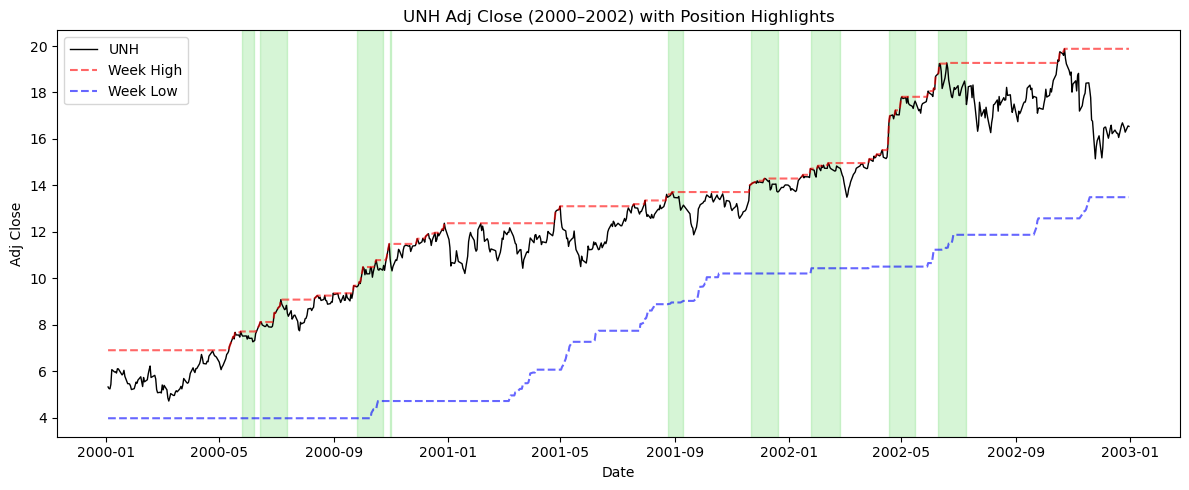

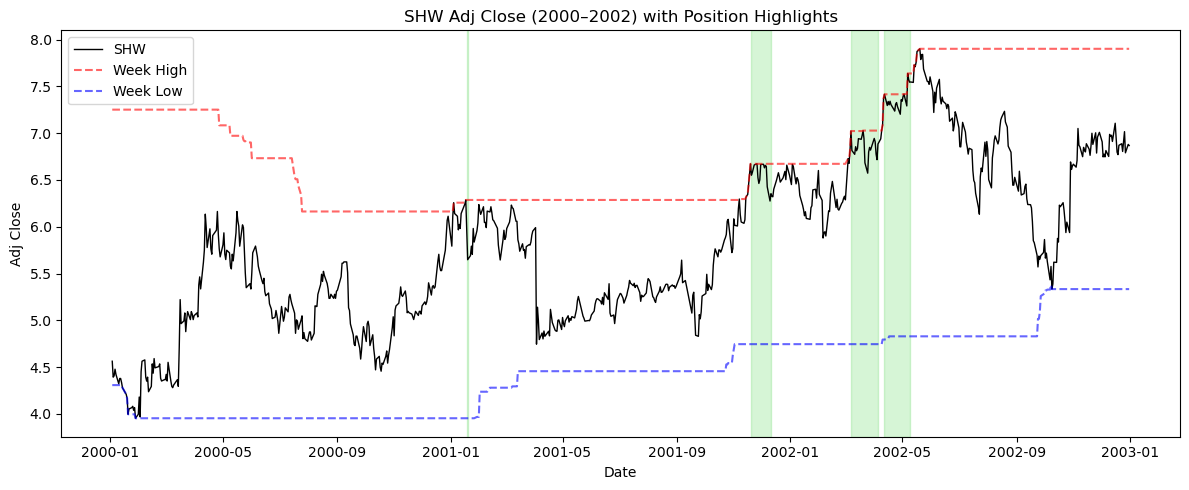

In [29]:
df_for_graph = combined_positions.reset_index()
df_for_graph['Date'] = pd.to_datetime(df_for_graph['Date'])
 
# Filter years and tickers
mask_graph = (df_for_graph['Date'] >= '2000-01-01') & (df_for_graph['Date'] <= '2002-12-31')
tickers_graph = ['UNH', 'SHW']
 
for ticker in tickers_graph:
    df_filtered_graph = df_for_graph[(df_for_graph['Ticker'] == ticker) & mask_graph].copy()
    df_filtered_graph.sort_values('Date', inplace=True)
    # Extract values
    date_graph = df_filtered_graph['Date']
    adj_close_graph = df_filtered_graph['Adj Close']
    position_graph = df_filtered_graph['position']
    plt.figure(figsize=(12, 5))

    # Main price line
    plt.plot(date_graph, adj_close_graph, label=ticker, color='black', linewidth=1)
 
    # Full-height green highlight where position == 1
    in_position = False
    start_date = None
 
    for i in range(len(df_filtered_graph)):
        if df_filtered_graph.iloc[i]['position'] == 1 and not in_position:
            start_date = df_filtered_graph.iloc[i]['Date']
            in_position = True
        elif df_filtered_graph.iloc[i]['position'] == 0 and in_position:
            end_date = df_filtered_graph.iloc[i]['Date']
            plt.axvspan(start_date, end_date, color='limegreen', alpha=0.2)
            in_position = False
    if in_position:
        plt.axvspan(start_date, df_filtered_graph.iloc[-1]['Date'], color='limegreen', alpha=0.2)
 
    # Dotted line for week high

    plt.plot(date_graph, df_filtered_graph['week_high'], linestyle='--', color='red', alpha=0.6, label='Week High')
 
    # Dotted line for week low

    plt.plot(date_graph, df_filtered_graph['week_low'], linestyle='--', color='blue', alpha=0.6, label='Week Low')
    plt.title(f'{ticker} Adj Close (2000–2002) with Position Highlights')
    plt.xlabel('Date')
    plt.ylabel('Adj Close')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

During the dotcom bubble, Sherwin Williams (Ticker: SHW) and United Health (Ticker: UNH) were the two stocks that had the most long positions in the Stock Active portfolio. We are going to analyze the price movements of these two stocks to evaluate whether a lack of momentum was responsible for the underperformance of the active strategy. SHW had a lot of buy signals in 2000-2002, but almost all buy signals were followed by significant price drops. As a result, during this periods, we bought the stock at high and sold at low, resulting in net loss from our position. On the other hand, the buy-and-hold strategy has a positive return during this period because it was immune from the interim price drops.
Similarly, most of UNH long positions in 2000-2002 resulted in losses. The reason is that the growth momentum of the stock was not strong enough and the stock was too volatile during the holding period that it triggers a stop-loss condition. 

## Is changing the holding period improve 52-week high/low work performance?

In [30]:
pd.set_option('display.width', 1000)  # Adjust the number as needed, or use None
pd.set_option('display.max_columns', None)

def big_func(dia_derived, djia_ex_dia_derived, volume_multiplier, stop_loss_rate, holding_period):
    # Part 1: dia_func logic
    i = 0
    while i < len(dia_derived): # change to while loop.
        # We are checking the long signal for index i
        if dia_derived['Adj Close'].iloc[i] == dia_derived['week_high'].iloc[i] and dia_derived['Volume'].iloc[i] > volume_multiplier * dia_derived['day_avg_vol'].iloc[i]:
            #Enter long position in index i + 1
            dia_derived.loc[i+1, 'position'] = 1
            #Extract entry price for i + 1
            entry_price = dia_derived['Adj Close'].iloc[i]
            entry_index = i
    
            # Check for 5% drop within the next 20 days
            for j in range(i + 1, min(i + (holding_period+1), len(dia_derived))):
                    if (j - entry_index) < holding_period: # check if less than 20 days.
                        if dia_derived['Adj Close'].iloc[j] < (1-stop_loss_rate) * entry_price:
                            dia_derived.loc[j+1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j+1  # Resume from the exit point
                            break
                    else: # 20 days have passed.
                        dia_derived.loc[j+1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j+1
                        break
        # We are checking the Short signal for index i
        elif dia_derived['Adj Close'].iloc[i] == dia_derived['week_low'].iloc[i] and dia_derived['Volume'].iloc[i] > volume_multiplier * dia_derived['day_avg_vol'].iloc[i]:
            #Enter short position in index i + 1
            dia_derived.loc[i+1, 'position'] = -1
            #Extract entry price for i + 1
            entry_price = dia_derived['Adj Close'].iloc[i] 
            entry_index = i
        
            # Check for 5% drop within the next 20 days
            for j in range(i + 1, min(i + (holding_period+1), len(dia_derived))):
                    if (j - entry_index) < holding_period: # check if less than 20 days.
                        if dia_derived['Adj Close'].iloc[j] > (1+stop_loss_rate) * entry_price:
                            dia_derived.loc[j+1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j+1  # Resume from the exit point
                            break
                    else: # 20 days have passed.
                        dia_derived.loc[j+1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j+1
                        break
    
        i += 1  # Increment i outside the if/else blocks
    
    dia_derived['position'] = dia_derived['position'].ffill()
    dia_derived['Strategy'] = dia_derived['position'] * dia_derived['Return']
    dia_derived['Strategy']= dia_derived['Strategy'].fillna(0)
    dia_derived.loc[dia_derived.index[1:], 'Strategy'] = np.where(
        dia_derived['Strategy'].iloc[1:] == 0, 
        dia_derived['RF'].iloc[1:], 
        dia_derived['Strategy'].iloc[1:]
    )
    # Part 2: djia_func logic
    for ticker in djia_ex_dia_derived['Ticker'].unique():
            df = djia_ex_dia_derived[djia_ex_dia_derived['Ticker'] == ticker].copy().reset_index(drop=True)
            df['position'] = np.nan  # Initialize position column
        
            entry_price = None
            entry_index = None
        
            i = 0
            while i < len(df):
                # Long Entry
                if (
                    df['Adj Close'].iloc[i] == df['week_high'].iloc[i]
                    and df['Volume'].iloc[i] > volume_multiplier * df['day_avg_vol'].iloc[i]
                ):
                    df.loc[i + 1, 'position'] = 1
                    entry_price = df['Adj Close'].iloc[i]
                    entry_index = i
        
                    for j in range(i + 1, min(i + (holding_period+1), len(df))):
                        if df['Adj Close'].iloc[j] < (1-stop_loss_rate) * entry_price:
                            df.loc[j + 1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j + 1
                            break
                        elif (j - entry_index) == holding_period:
                            df.loc[j + 1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j + 1
                            break
        
                # Short Entry
                elif (
                    df['Adj Close'].iloc[i] == df['week_low'].iloc[i]
                    and df['Volume'].iloc[i] > volume_multiplier * df['day_avg_vol'].iloc[i]
                ):
                    df.loc[i + 1, 'position'] = -1
                    entry_price = df['Adj Close'].iloc[i]
                    entry_index = i
        
                    for j in range(i + 1, min(i + (holding_period+1), len(df))):
                        if df['Adj Close'].iloc[j] > (1+stop_loss_rate) * entry_price:
                            df.loc[j + 1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j + 1
                            break
                        elif (j - entry_index) == holding_period:
                            df.loc[j + 1, 'position'] = 0
                            entry_price = None
                            entry_index = None
                            i = j + 1
                            break
        
                i += 1  # Always increment i if no entry/exit triggered
        
            positions_by_ticker[ticker] = df
            
    combined_positions = pd.concat(positions_by_ticker.values(), ignore_index=True)
    combined_positions = combined_positions.set_index(['Date','Ticker']).unstack(level='Ticker')
    combined_positions['position'] = combined_positions['position'].ffill()
    _ = pd.MultiIndex.from_product([['Stock Strategy'],combined_positions['Adj Close'].columns])
    combined_positions[_] = combined_positions['position']*combined_positions['Return']
    combined_positions = combined_positions.stack()
    portfolio = combined_positions.groupby('Date').apply(lambda x: x['position'].abs().sum())
    portfolio = portfolio.to_frame(name = 'Total_Position')
    portfolio['Total Stock Return'] = combined_positions.groupby('Date')['Stock Strategy'].sum()
    portfolio['Strategy'] = portfolio['Total Stock Return']/portfolio['Total_Position']
    portfolio['Strategy'] = portfolio['Strategy'].fillna(0)
    portfolio = portfolio.merge(ff3[['Date','RF']], on = 'Date', how = 'left')
    portfolio['RF'] = portfolio['RF']/252

    # Part 3: iter_func logic
    # Note: `portfolio` variable here is the one calculated just above, not an input.
    # This also uses `dia_derived` which was modified by Part 1.
    # The indexing `dia_derived.index[1:]` assumes dia_derived has a compatible index with portfolio
    portfolio.loc[dia_derived.index[1:], 'Strategy'] = np.where(
        portfolio['Strategy'].iloc[1:] == 0,
        portfolio['RF'].iloc[1:],
        portfolio['Strategy'].iloc[1:]
    )
    # Assumes portfolio has 'Date' column for concatenation
    # Assumes dia_derived has 'Strategy' and 'Return' columns
    three_strategies = pd.concat([
        portfolio[['Date', 'Strategy']],
        dia_derived[['Strategy', 'Return']]
    ], axis=1)
    three_strategies.columns = ['Date','Stock Active','DIA Active','DIA Passive']
    
    three_strategies = three_strategies.set_index('Date', drop=True)
    if not isinstance(three_strategies.index, pd.DatetimeIndex):
        three_strategies.index = pd.to_datetime(three_strategies.index)
    
    # Calculate cumulative product after adding 1
    cumulative_returns = three_strategies.add(1).cumprod()
    
    # Plotting with enhancements
    plt.figure(figsize=(30, 8))  # Even larger figure for a longer x-axis
    cumulative_returns.plot(linewidth=2)  # Thicker lines
    
    plt.semilogy()  # Logarithmic y-axis
    
    plt.title('Cumulative Returns (Log Scale)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Returns', fontsize=12)
    
    plt.legend(fontsize=12)
    
    # Format x-axis dates
    plt.gca().xaxis.set_major_locator(mdates.YearLocator()) # show every 6 months
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Year-month format
    plt.xticks(rotation=45, ha='right')  # Tilted labels, right-aligned
    
    plt.tight_layout()  # Prevent label clipping
    plt.show()
    
    last_valid_date = three_strategies.add(1).cumprod().last_valid_index()
    last_row = three_strategies.add(1).cumprod().loc[[last_valid_date]]

    last_row['volume_multiplier'] = volume_multiplier
    last_row['stop_loss_rate'] = stop_loss_rate
    last_row['holding_period'] = holding_period

    # This line already exists: prints the result
    return last_row
    # Note: The function doesn't explicitly return anything.

In [31]:
# INPUTS FOR VARIABLES:

volume_multiplier = [1.5]
stop_loss_rate = [0.05]
holding_period = [20,30,40,50]

Starting parameter sweep using itertools.product...
Running with: VM=1.5, SL=0.05, HP=20


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\3960917787.py:130: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  combined_positions = combined_positions.stack()


<Figure size 3000x800 with 0 Axes>

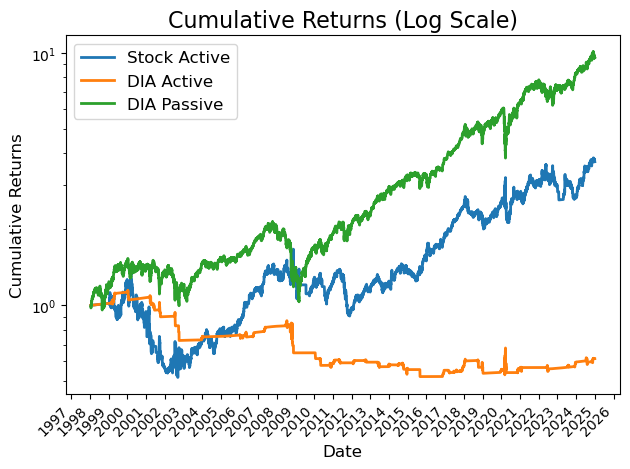

Running with: VM=1.5, SL=0.05, HP=30


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\3960917787.py:130: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  combined_positions = combined_positions.stack()


<Figure size 3000x800 with 0 Axes>

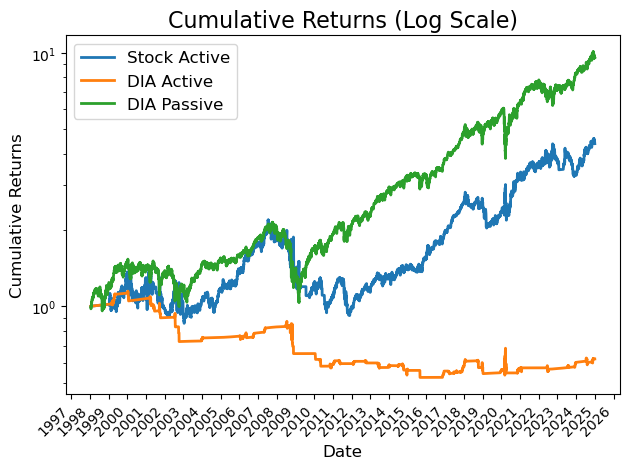

Running with: VM=1.5, SL=0.05, HP=40


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\3960917787.py:130: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  combined_positions = combined_positions.stack()


<Figure size 3000x800 with 0 Axes>

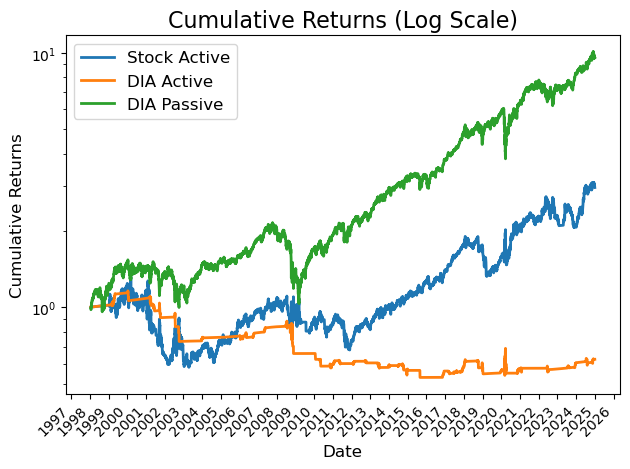

Running with: VM=1.5, SL=0.05, HP=50


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\3960917787.py:130: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  combined_positions = combined_positions.stack()


<Figure size 3000x800 with 0 Axes>

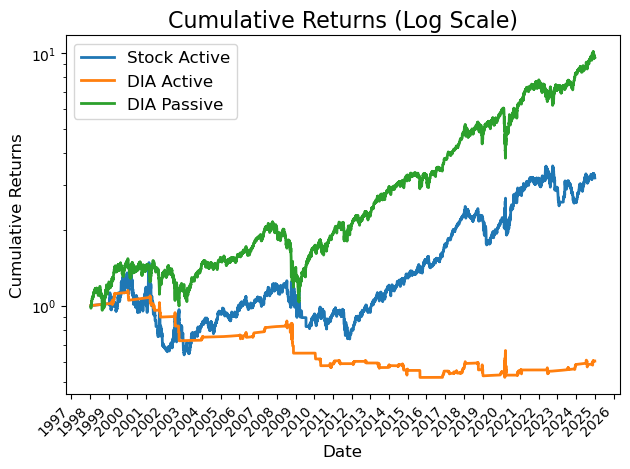

Parameter sweep finished.

--- Combined Results ---


,Stock Active,DIA Active,DIA Passive,volume_multiplier,stop_loss_rate,holding_period
Date,,,,,,
2024-12-31,3.7032,0.6154,9.5593,1.5000,0.0500,20
2024-12-31,4.3780,0.6197,9.5593,1.5000,0.0500,30
2024-12-31,2.9523,0.6235,9.5593,1.5000,0.0500,40
2024-12-31,3.1983,0.6038,9.5593,1.5000,0.0500,50


In [32]:
all_results = []

# --- Use itertools.product to generate combinations ---
print("Starting parameter sweep using itertools.product...")
param_combinations = itertools.product(
    volume_multiplier,
    stop_loss_rate,
    holding_period
)

# --- Loop through the generated combinations ---
for params in param_combinations:
    # Unpack the parameters from the tuple
    vm, slr, hp = params

    print(f"Running with: VM={vm}, SL={slr}, HP={hp}")

    # Call big_func with copies of original data and current parameters
    result_row = big_func(
        dia_derived.copy(), # Pass copy
        djia_ex_dia_derived.copy(), # Pass copy
        vm,
        slr,
        hp
    )

    # Append the result if it's not None
    if result_row is not None:
        all_results.append(result_row)

print("Parameter sweep finished.")

# --- Combine all results into a single DataFrame ---

final_results_df = pd.concat(all_results)
# Optional: Reset index if Date index is duplicated from multiple runs
# final_results_df = final_results_df.reset_index()
print("\n--- Combined Results ---")
final_results_df

In [33]:
entry_price = None
entry_index = None

i = 0
while i < len(dia_derived): # change to while loop.
    # We are checking the long signal for index i
    if dia_derived['Adj Close'].iloc[i] == dia_derived['week_high'].iloc[i] and dia_derived['Volume'].iloc[i] > 1.5 * dia_derived['day_avg_vol'].iloc[i]:
        #Enter long position in index i + 1
        dia_derived.loc[i+1, 'position'] = 1
        #Extract entry price for i + 1
        entry_price = dia_derived['Adj Close'].iloc[i]
        entry_index = i

        # Check for 5% drop within the next 20 days
        for j in range(i + 1, min(i + 21, len(dia_derived))):
                if (j - entry_index) < 20: # check if less than 20 days.
                    if dia_derived['Adj Close'].iloc[j] < 0.95 * entry_price:
                        dia_derived.loc[j+1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j+1  # Resume from the exit point
                        break
                else: # 20 days have passed.
                    dia_derived.loc[j+1, 'position'] = 0
                    entry_price = None
                    entry_index = None
                    i = j+1
                    break
    # We are checking the Short signal for index i
    elif dia_derived['Adj Close'].iloc[i] == dia_derived['week_low'].iloc[i] and dia_derived['Volume'].iloc[i] > 1.5 * dia_derived['day_avg_vol'].iloc[i]:
        #Enter short position in index i + 1
        dia_derived.loc[i+1, 'position'] = -1
        #Extract entry price for i + 1
        entry_price = dia_derived['Adj Close'].iloc[i] 
        entry_index = i
    
        # Check for 5% drop within the next 20 days
        for j in range(i + 1, min(i + 21, len(dia_derived))):
                if (j - entry_index) < 20: # check if less than 20 days.
                    if dia_derived['Adj Close'].iloc[j] > 1.05 * entry_price:
                        dia_derived.loc[j+1, 'position'] = 0
                        entry_price = None
                        entry_index = None
                        i = j+1  # Resume from the exit point
                        break
                else: # 20 days have passed.
                    dia_derived.loc[j+1, 'position'] = 0
                    entry_price = None
                    entry_index = None
                    i = j+1
                    break

    i += 1  # Increment i outside the if/else blocks    

    # Feature generation
signal_data = []

dia_derived['position'] = np.nan
dia_derived['Return'] = dia_derived['Adj Close'].pct_change()

entry_price = None
entry_index = None

i = 0
while i < len(dia_derived):  # Signal generation for labeling position
    if (
        dia_derived['Adj Close'].iloc[i] == dia_derived['week_high'].iloc[i]
        and dia_derived['Volume'].iloc[i] > 1.5 * dia_derived['day_avg_vol'].iloc[i]
    ):
        dia_derived.loc[i + 1, 'position'] = 1
        entry_price = dia_derived['Adj Close'].iloc[i]
        entry_index = i

        for j in range(i + 1, min(i + 21, len(dia_derived))):
            if dia_derived['Adj Close'].iloc[j] < 0.95 * entry_price:
                dia_derived.loc[j + 1, 'position'] = 0
                i = j + 1
                break
            elif (j - entry_index) == 20:
                dia_derived.loc[j + 1, 'position'] = 0
                i = j + 1
                break

    elif (
        dia_derived['Adj Close'].iloc[i] == dia_derived['week_low'].iloc[i]
        and dia_derived['Volume'].iloc[i] > 1.5 * dia_derived['day_avg_vol'].iloc[i]
    ):
        dia_derived.loc[i + 1, 'position'] = -1
        entry_price = dia_derived['Adj Close'].iloc[i]
        entry_index = i

        for j in range(i + 1, min(i + 21, len(dia_derived))):
            if dia_derived['Adj Close'].iloc[j] > 1.05 * entry_price:
                dia_derived.loc[j + 1, 'position'] = 0
                i = j + 1
                break
            elif (j - entry_index) == 20:
                dia_derived.loc[j + 1, 'position'] = 0
                i = j + 1
                break

    i += 1


# Feature generation
signal_data_dia = []

dia_derived['position_dia'] = np.nan
dia_derived['Return_dia'] = dia_derived['Adj Close'].pct_change()

entry_price_dia = None
entry_index_dia = None

i_dia = 0
while i_dia < len(dia_derived):
    if (
        dia_derived['Adj Close'].iloc[i_dia] == dia_derived['week_high'].iloc[i_dia]
        and dia_derived['Volume'].iloc[i_dia] > 1.5 * dia_derived['day_avg_vol'].iloc[i_dia]
    ):
        dia_derived.loc[i_dia + 1, 'position_dia'] = 1
        entry_price_dia = dia_derived['Adj Close'].iloc[i_dia]
        entry_index_dia = i_dia

        for j_dia in range(i_dia + 1, min(i_dia + 21, len(dia_derived))):
            if dia_derived['Adj Close'].iloc[j_dia] < 0.95 * entry_price_dia:
                dia_derived.loc[j_dia + 1, 'position_dia'] = 0
                i_dia = j_dia + 1
                break
            elif (j_dia - entry_index_dia) == 20:
                dia_derived.loc[j_dia + 1, 'position_dia'] = 0
                i_dia = j_dia + 1
                break

    elif (
        dia_derived['Adj Close'].iloc[i_dia] == dia_derived['week_low'].iloc[i_dia]
        and dia_derived['Volume'].iloc[i_dia] > 1.5 * dia_derived['day_avg_vol'].iloc[i_dia]
    ):
        dia_derived.loc[i_dia + 1, 'position_dia'] = -1
        entry_price_dia = dia_derived['Adj Close'].iloc[i_dia]
        entry_index_dia = i_dia

        for j_dia in range(i_dia + 1, min(i_dia + 21, len(dia_derived))):
            if dia_derived['Adj Close'].iloc[j_dia] > 1.05 * entry_price_dia:
                dia_derived.loc[j_dia + 1, 'position_dia'] = 0
                i_dia = j_dia + 1
                break
            elif (j_dia - entry_index_dia) == 20:
                dia_derived.loc[j_dia + 1, 'position_dia'] = 0
                i_dia = j_dia + 1
                break

    i_dia += 1


# DIA feature extraction
df_dia = dia_derived.copy().reset_index(drop=True)
ticker_dia = "DIA"

i_dia = 10
while i_dia < len(df_dia) - 21:
    # Long Entry
    if (
        df_dia['Adj Close'].iloc[i_dia] == df_dia['week_high'].iloc[i_dia]
        and df_dia['Volume'].iloc[i_dia] > 1.5 * df_dia['day_avg_vol'].iloc[i_dia]
    ):
        entry_date_dia = df_dia['Date'].iloc[i_dia + 1]
        direction_dia = 'long'
        entry_price_dia = df_dia['Adj Close'].iloc[i_dia]
        exit_price_dia = None
        outcome_dia = 0

        for j_dia in range(1, 21):
            if i_dia + j_dia >= len(df_dia):
                break
            future_price_dia = df_dia['Adj Close'].iloc[i_dia + j_dia]
            if future_price_dia <= 0.95 * entry_price_dia:
                outcome_dia = 0
                exit_price_dia = future_price_dia
                break
        else:
            final_exit_index_dia = min(i_dia + 20, len(df_dia) - 1)
            exit_price_dia = df_dia['Adj Close'].iloc[final_exit_index_dia]
            exit_date_dia = df_dia['Date'].iloc[final_exit_index_dia]
            outcome_dia = 1 if exit_price_dia > entry_price_dia else 0

        volume_spike_dia = df_dia['Volume'].iloc[i_dia] / df_dia['day_avg_vol'].iloc[i_dia] if df_dia['day_avg_vol'].iloc[i_dia] != 0 else np.nan
        momentum_10d_dia = df_dia['Adj Close'].iloc[i_dia] / df_dia['Adj Close'].iloc[i_dia - 10] - 1
        volatility_10d_dia = df_dia['Return'].iloc[i_dia - 10:i_dia].std()
        exit_date_dia = df_dia['Date'].iloc[i_dia + j_dia + 1]

        signal_data_dia.append({
            'entry_date': entry_date_dia,
            'exit_date': exit_date_dia,
            'ticker': ticker_dia,
            'direction': direction_dia,
            'outcome': outcome_dia,
            'volume_spike': volume_spike_dia,
            'momentum_10d': momentum_10d_dia,
            'volatility_10d': volatility_10d_dia,
            'Returns': (exit_price_dia / entry_price_dia) - 1 #we are calculating the returns from the entry price to the exit price
        })

        i_dia += j_dia
        continue

    # Short Entry
    if (
        df_dia['Adj Close'].iloc[i_dia] == df_dia['week_low'].iloc[i_dia]
        and df_dia['Volume'].iloc[i_dia] > 1.5 * df_dia['day_avg_vol'].iloc[i_dia]
    ):
        entry_date_dia = df_dia['Date'].iloc[i_dia + 1]
        direction_dia = 'short'
        entry_price_dia = df_dia['Adj Close'].iloc[i_dia]
        exit_price_dia = None
        outcome_dia = 0

        for j_dia in range(1, 21):
            if i_dia + j_dia >= len(df_dia):
                break
            future_price_dia = df_dia['Adj Close'].iloc[i_dia + j_dia]
            if future_price_dia >= 1.05 * entry_price_dia:
                outcome_dia = 0
                exit_price_dia = future_price_dia
                break
        else:
            final_exit_index_dia = min(i_dia + 20, len(df_dia) - 1)
            exit_price_dia = df_dia['Adj Close'].iloc[final_exit_index_dia]
            exit_date_dia = df_dia['Date'].iloc[final_exit_index_dia]
            outcome_dia = 1 if exit_price_dia < entry_price_dia else 0

        volume_spike_dia = df_dia['Volume'].iloc[i_dia] / df_dia['day_avg_vol'].iloc[i_dia] if df_dia['day_avg_vol'].iloc[i_dia] != 0 else np.nan
        momentum_10d_dia = df_dia['Adj Close'].iloc[i_dia] / df_dia['Adj Close'].iloc[i_dia - 10] - 1
        volatility_10d_dia = df_dia['Return_dia'].iloc[i_dia - 10:i_dia].std()
        exit_date_dia = df_dia['Date'].iloc[i_dia + j_dia + 1]


        signal_data_dia.append({
            'entry_date': entry_date_dia,
            'exit_date': exit_date_dia,
            'ticker': ticker_dia,
            'direction': direction_dia,
            'outcome': outcome_dia,
            'volume_spike': volume_spike_dia,
            'momentum_10d': momentum_10d_dia,
            'volatility_10d': volatility_10d_dia,
            'Returns': (entry_price_dia / exit_price_dia) - 1 #we are calculating the returns from the entry price to the exit price
        })

        i_dia += j_dia
        continue

    i_dia += 1

signal_analysis_df_dia = pd.DataFrame(signal_data_dia)


In [34]:
dia_derived['position'] = dia_derived['position'].ffill()   

In [35]:
dia_derived['Strategy'] = dia_derived['position'] * dia_derived['Return']
dia_derived['Strategy']= dia_derived['Strategy'].fillna(0)
dia_derived.loc[dia_derived.index[1:], 'Strategy'] = np.where(
    dia_derived['Strategy'].iloc[1:] == 0, 
    dia_derived['RF'].iloc[1:], 
    dia_derived['Strategy'].iloc[1:]
)

In [36]:
positions_by_ticker = {}
signal_data = []

for ticker in djia_ex_dia_derived['Ticker'].unique():
    df = djia_ex_dia_derived[djia_ex_dia_derived['Ticker'] == ticker].copy().reset_index(drop=True)
    df['position'] = np.nan
    df['Return'] = df['Adj Close'].pct_change()  # For volatility

    entry_price = None
    entry_index = None
    i = 0

    while i < len(df):
        # Long Entry
        if (
            df['Adj Close'].iloc[i] == df['week_high'].iloc[i]
            and df['Volume'].iloc[i] > 1.5 * df['day_avg_vol'].iloc[i]
        ):
            df.loc[i + 1, 'position'] = 1
            entry_price = df['Adj Close'].iloc[i]
            entry_index = i

            for j in range(i + 1, min(i + 21, len(df))):
                if df['Adj Close'].iloc[j] < 0.95 * entry_price:
                    df.loc[j + 1, 'position'] = 0
                    entry_price = None
                    entry_index = None
                    i = j + 1
                    break
                elif (j - entry_index) == 20:
                    df.loc[j + 1, 'position'] = 0
                    entry_price = None
                    entry_index = None
                    i = j + 1
                    break

        # Short Entry
        elif (
            df['Adj Close'].iloc[i] == df['week_low'].iloc[i]
            and df['Volume'].iloc[i] > 1.5 * df['day_avg_vol'].iloc[i]
        ):
            df.loc[i + 1, 'position'] = -1
            entry_price = df['Adj Close'].iloc[i]
            entry_index = i

            for j in range(i + 1, min(i + 21, len(df))):
                if df['Adj Close'].iloc[j] > 1.05 * entry_price:
                    df.loc[j + 1, 'position'] = 0
                    entry_price = None
                    entry_index = None
                    i = j + 1
                    break
                elif (j - entry_index) == 20:
                    df.loc[j + 1, 'position'] = 0
                    entry_price = None
                    entry_index = None
                    i = j + 1
                    break

        i += 1

    df['position'] = df['position'].ffill()
    positions_by_ticker[ticker] = df

    # Feature generation
signal_data = []

for ticker in djia_ex_dia_derived['Ticker'].unique():
    df = djia_ex_dia_derived[djia_ex_dia_derived['Ticker'] == ticker].copy().reset_index(drop=True)
    df['Return'] = df['Adj Close'].pct_change()

    i = 10
    while i < len(df) - 21:
        # Long Entry Condition
        if (
            df['Adj Close'].iloc[i] == df['week_high'].iloc[i]
            and df['Volume'].iloc[i] > 1.5 * df['day_avg_vol'].iloc[i]
        ):
            entry_date = df['Date'].iloc[i+1]
            direction = 'long'
            entry_price = df['Adj Close'].iloc[i]
            outcome = 0
            exit_price = None

            for j in range(1, 21):
                if i + j >= len(df):
                    break
                future_price = df['Adj Close'].iloc[i + j]
                if future_price <= 0.95 * entry_price:
                    outcome = 0
                    exit_price = future_price
                    break
                else:
                    # No 5% target hit — check where price ended at day 20
                    final_exit_index = min(i + j, len(df) - 1)
                    exit_price = df['Adj Close'].iloc[final_exit_index]
                    exit_date = df['Date'].iloc[final_exit_index]
                    outcome = 1 if exit_price > entry_price else 0


            volume_spike = (
                df['Volume'].iloc[i] / df['day_avg_vol'].iloc[i]
                if df['day_avg_vol'].iloc[i] != 0 else np.nan
            )
            momentum_10d = df['Adj Close'].iloc[i] / df['Adj Close'].iloc[i - 10] - 1
            volatility_10d = df['Return'].iloc[i-10:i].std()
            exit_date = df['Date'].iloc[i + j + 1]

            signal_data.append({
                'entry_date': entry_date,
                'exit_date': exit_date,
                'ticker': ticker,
                'direction': direction,
                'outcome': outcome,
                'volume_spike': volume_spike,
                'momentum_10d': momentum_10d,
                'volatility_10d': volatility_10d,
                'Returns': (exit_price / entry_price) - 1 #we are calculating the returns from the entry price to the exit price
            })

            i += j
            continue

        # Short Entry Condition
        if (
            df['Adj Close'].iloc[i] == df['week_low'].iloc[i]
            and df['Volume'].iloc[i] > 1.5 * df['day_avg_vol'].iloc[i]
        ):
            entry_date = df['Date'].iloc[i+1]
            direction = 'short'
            entry_price = df['Adj Close'].iloc[i]
            outcome = 0
            exit_price = None

            for j in range(1, 21):
                if i + j >= len(df):
                    break
                future_price = df['Adj Close'].iloc[i + j]
                if future_price >= 1.05 * entry_price:
                    outcome = 0
                    exit_price = future_price
                    break
                else:
                    # No 5% target hit — check where price ended at day 20
                    final_exit_index = min(i + j, len(df) - 1)
                    exit_price = df['Adj Close'].iloc[final_exit_index]
                    exit_date = df['Date'].iloc[final_exit_index]
                    outcome = 1 if exit_price < entry_price else 0


            volume_spike = (
                df['Volume'].iloc[i] / df['day_avg_vol'].iloc[i]
                if df['day_avg_vol'].iloc[i] != 0 else np.nan
            )
            momentum_10d = df['Adj Close'].iloc[i] / df['Adj Close'].iloc[i - 10] - 1
            volatility_10d = df['Return'].iloc[i-10:i].std()
            exit_date = df['Date'].iloc[i + j + 1]

            signal_data.append({
                'entry_date': entry_date,
                'exit_date': exit_date,
                'ticker': ticker,
                'direction': direction,
                'outcome': outcome,
                'volume_spike': volume_spike,
                'momentum_10d': momentum_10d,
                'volatility_10d': volatility_10d,
                'Returns': (entry_price / exit_price) - 1 #we are calculating the returns from the entry price to the exit price
            })

            i += j
            continue

        i += 1

signal_analysis_df = pd.DataFrame(signal_data)


We tested different holding period length to see if 20-day holding period is optimal. Our test showed that the active strategy works best if the holding period increases to 30 days. Once we increase the holding period to 40 days or more, however, the performance of the portfolio decreases. That means the relationship between the holding period and the strategy performance might be quandratic.

## Does adding extra factors improve 52-week high/low work performance?

In [37]:
# Baseline win rate (all trades)
baseline_winrate = signal_analysis_df['outcome'].mean()

# Apply your filters
filtered_signals = signal_analysis_df[
    (signal_analysis_df['volume_spike'] > 2.1) &
    (signal_analysis_df['momentum_10d'] > 0.025) &
    (signal_analysis_df['volatility_10d'] < 0.015) 
]

# Win rate after filtering
filtered_winrate = filtered_signals['outcome'].mean()
Diff_winrate = (filtered_winrate - baseline_winrate)

print(
    f"Baseline win rate: {baseline_winrate:.2%} | "
    f"Filtered win rate: {filtered_winrate:.2%} | "
    f"Total trades: {len(signal_analysis_df)} | "
    f"Filtered trades: {len(filtered_signals)} | "
    f"Win rate improvement: {Diff_winrate:.2%}"
)


Baseline win rate: 49.10% | Filtered win rate: 62.64% | Total trades: 1552 | Filtered trades: 265 | Win rate improvement: 13.54%


In [38]:
# Baseline win rate (all trades)
baseline_winrate_dia = signal_analysis_df_dia['outcome'].mean()

# Apply your filters
filtered_signals_dia = signal_analysis_df_dia[
    (signal_analysis_df_dia['volume_spike'] > 1.6) &
    (signal_analysis_df_dia['momentum_10d'] > 0.0150) &
    (signal_analysis_df_dia['volatility_10d'] < 0.035) 
]

# Win rate after filtering
filtered_winrate_dia = filtered_signals_dia['outcome'].mean()
Diff_winrate_dia = (filtered_winrate_dia - baseline_winrate_dia)

print(
    f"Baseline win rate: {baseline_winrate_dia:.2%} | "
    f"Filtered win rate: {filtered_winrate_dia:.2%} | "
    f"Total trades: {len(signal_analysis_df_dia)} | "
    f"Filtered trades: {len(filtered_signals_dia)} | "
    f"Win rate improvement: {Diff_winrate_dia:.2%}"
)


Baseline win rate: 51.92% | Filtered win rate: 70.59% | Total trades: 52 | Filtered trades: 17 | Win rate improvement: 18.67%


In [39]:
results = []

volume_thresholds = np.linspace(1.2, 2.1, 10)       # 10 values
momentum_thresholds = np.linspace(0.005, 0.045, 9)  # 9 values
volatility_thresholds = np.linspace(0.015, 0.055, 9) # 9 values

for vol_spike in volume_thresholds:
    for mom in momentum_thresholds:
        for vol in volatility_thresholds:
            filtered = signal_analysis_df[
                (signal_analysis_df['volume_spike'] > vol_spike) &
                (signal_analysis_df['momentum_10d'] > mom) &
                (signal_analysis_df['volatility_10d'] < vol) 
                
            ]
            win_rate = filtered['outcome'].mean() if len(filtered) > 0 else np.nan
            results.append({
                'volume_spike_thresh': vol_spike,
                'momentum_thresh': mom,
                'volatility_thresh': vol,
                'num_trades': len(filtered),
                'win_rate': win_rate
            })

results_df = pd.DataFrame(results)
results_df = results_df.dropna().sort_values(by='win_rate', ascending=False).reset_index(drop=True)

In [40]:
results_dia = []

volume_thresholds_dia = np.linspace(1.2, 2.1, 10)       # 10 values
momentum_thresholds_dia = np.linspace(0.005, 0.045, 9)  # 9 values
volatility_thresholds_dia = np.linspace(0.015, 0.055, 9) # 9 values

for vol_spike_dia in volume_thresholds_dia:
    for mom_dia in momentum_thresholds_dia:
        for vol_dia in volatility_thresholds_dia:
            filtered_dia = signal_analysis_df_dia[
                (signal_analysis_df_dia['volume_spike'] > vol_spike_dia) &
                (signal_analysis_df_dia['momentum_10d'] > mom_dia) &
                (signal_analysis_df_dia['volatility_10d'] < vol_dia) 
                
            ]
            win_rate_dia = filtered_dia['outcome'].mean() if len(filtered_dia) > 0 else np.nan
            results_dia.append({
                'volume_spike_thresh': vol_spike_dia,
                'momentum_thresh': mom_dia,
                'volatility_thresh': vol_dia,
                'num_trades': len(filtered_dia),
                'win_rate': win_rate_dia
            })

results_df_dia = pd.DataFrame(results_dia)
results_df_dia = results_df_dia.dropna().sort_values(by='win_rate', ascending=False).reset_index(drop=True)

In [41]:
three_strategies = pd.concat([
    portfolio[['Date', 'Strategy']],
    dia_derived[['Strategy', 'Return']]
], axis=1)
three_strategies.columns = ['Date','Stock Active','DIA Active','DIA Passive']


In [42]:
three_strategies = three_strategies.set_index('Date', drop=True)

In [43]:
# --- For Stock Active (filtered signals) ---

# Get dates and tickers from filtered trades
filtered_dates = filtered_signals[['entry_date', 'exit_date', 'ticker']]

# Pull those positions from original `positions_by_ticker`
filtered_stock_positions = []
for _, row in filtered_dates.iterrows():
    df = positions_by_ticker[row['ticker']]
    sub_df = df[(df['Date'] >= row['entry_date']) & (df['Date'] <= row['exit_date'])].copy()
    sub_df['Ticker'] = row['ticker']
    filtered_stock_positions.append(sub_df)

# Combine into one DataFrame
filtered_positions_combined = pd.concat(filtered_stock_positions).reset_index(drop=True)

# Create the position*return logic
filtered_positions_combined = filtered_positions_combined.drop_duplicates(subset=['Date', 'Ticker'])
filtered_positions_combined = filtered_positions_combined.set_index(['Date','Ticker']).unstack(level='Ticker')


_ = pd.MultiIndex.from_product([['Filtered Stock Strategy'], filtered_positions_combined['Adj Close'].columns])
filtered_positions_combined[_] = (
    filtered_positions_combined['position'] * filtered_positions_combined['Return']
)

filtered_positions_combined = filtered_positions_combined.stack()

# Aggregate into portfolio
filtered_portfolio = filtered_positions_combined.groupby('Date').apply(lambda x: x['position'].abs().sum()).to_frame(name='Total_Position')
filtered_portfolio['Filtered Stock Return'] = filtered_positions_combined.groupby('Date')['Filtered Stock Strategy'].sum()
filtered_portfolio['Strategy'] = filtered_portfolio['Filtered Stock Return'] / filtered_portfolio['Total_Position']
filtered_portfolio['Strategy'] = filtered_portfolio['Strategy'].fillna(0)

# Add RF
filtered_portfolio = filtered_portfolio.merge(ff3[['Date','RF']], on='Date', how='left')
filtered_portfolio['RF'] = filtered_portfolio['RF'] / 252
filtered_portfolio.loc[filtered_portfolio.index[1:], 'Strategy'] = np.where(
    filtered_portfolio['Strategy'].iloc[1:] == 0,
    filtered_portfolio['RF'].iloc[1:],
    filtered_portfolio['Strategy'].iloc[1:]
)


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\1395174630.py:27: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  filtered_positions_combined = filtered_positions_combined.stack()


In [44]:
# Make sure all relevant columns are datetime
dia_derived['Date'] = pd.to_datetime(dia_derived['Date'])
filtered_signals_dia['entry_date'] = pd.to_datetime(filtered_signals_dia['entry_date'])
filtered_signals_dia['exit_date'] = pd.to_datetime(filtered_signals_dia['exit_date'])

# Create DIA filtered strategy time series
dia_filtered_segments = []

for _, row in filtered_signals_dia.iterrows():
    temp = dia_derived[
        (dia_derived['Date'] >= row['entry_date']) &
        (dia_derived['Date'] <= row['exit_date'])
    ].copy()
    if not temp.empty:
        dia_filtered_segments.append(temp)

# Combine all valid segments
if dia_filtered_segments:
    dia_filtered = pd.concat(dia_filtered_segments).drop_duplicates(subset='Date').sort_values(by='Date').reset_index(drop=True)
else:
    dia_filtered = pd.DataFrame(columns=dia_derived.columns)  # empty fallback to prevent error

# Forward fill the position signal
if not dia_filtered.empty:
    dia_filtered['position'] = dia_filtered['position'].ffill()

    # Ensure no missing values in 'position' before calculating strategy
    dia_filtered['position'] = dia_filtered['position'].fillna(0)

    # Calculate filtered DIA strategy returns
    dia_filtered['Strategy'] = dia_filtered['position'] * dia_filtered['Return']
    dia_filtered['Strategy'] = dia_filtered['Strategy'].fillna(0)

    # Apply risk-free fallback when strategy return is zero
    dia_filtered['Strategy'] = np.where(
        dia_filtered['Strategy'] == 0,
        dia_filtered['RF'] / 252,  # assuming RF is annualized
        dia_filtered['Strategy']
    )


C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\769426337.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_signals_dia['entry_date'] = pd.to_datetime(filtered_signals_dia['entry_date'])
C:\Users\mardy\AppData\Local\Temp\ipykernel_24760\769426337.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_signals_dia['exit_date'] = pd.to_datetime(filtered_signals_dia['exit_date'])


In [45]:
three_strategies_filtered = pd.concat([
    filtered_portfolio[['Date', 'Strategy']].rename(columns={'Strategy': 'Stock Active Filtered'}),
    dia_filtered[['Date', 'Strategy', 'Return']].rename(columns={
        'Strategy': 'DIA Active Filtered',
        'Return': 'DIA Passive'
    }).drop(columns=['Date'])  # ← drop extra 'Date' here
], axis=1)

three_strategies_filtered = three_strategies_filtered.set_index('Date')



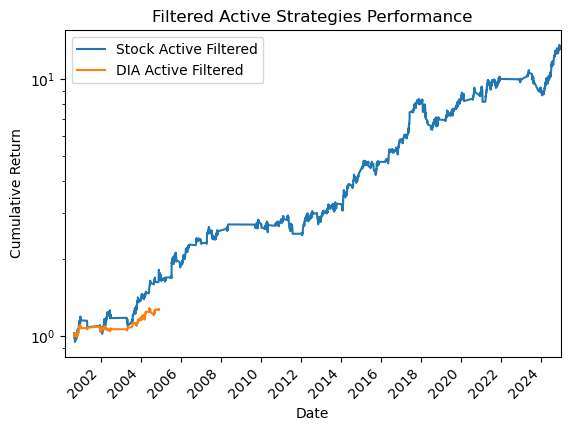

In [46]:
# Ensure datetime index
three_strategies_filtered.index = pd.to_datetime(three_strategies_filtered.index)

# Dynamically set x-axis range
start_date = three_strategies_filtered.dropna(how='all').index.min() - pd.Timedelta(days=180)
end_date = three_strategies_filtered.dropna(how='all').index.max()

# Plot
three_strategies_filtered[['Stock Active Filtered', 'DIA Active Filtered']].add(1).cumprod().plot(
    title='Filtered Active Strategies Performance',
    grid=False,
    logy=True
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.xlim(start_date, end_date)  # apply the dynamic date range

plt.legend()
plt.show()


Our experiment shows a significant improvement in the Stock Active performance when two new factors are added. 